In [1]:
# imports
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import os
import numpy as np

In [2]:
# config
OUT_DIR = "results_fairness_over_time"
BIAS_ML_CSV = os.path.join(OUT_DIR, "bias_crows_pairs_multilingual.csv")

dfb = pd.read_csv(BIAS_ML_CSV).sort_values(["year","model_id","lang"]).reset_index(drop=True)

In [3]:
def scatter_models_legend(df, xcol, ycol, title, xlabel, ylabel, x_is_year=False):
    fig, ax = plt.subplots(figsize=(15, 6))
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].astype(int).unique())
        ax.set_xticks(years)
    ax.grid(True, linewidth=0.5, alpha=0.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=7)
    fig.tight_layout(rect=[0, 0, 0.75, 1])
    plt.show()

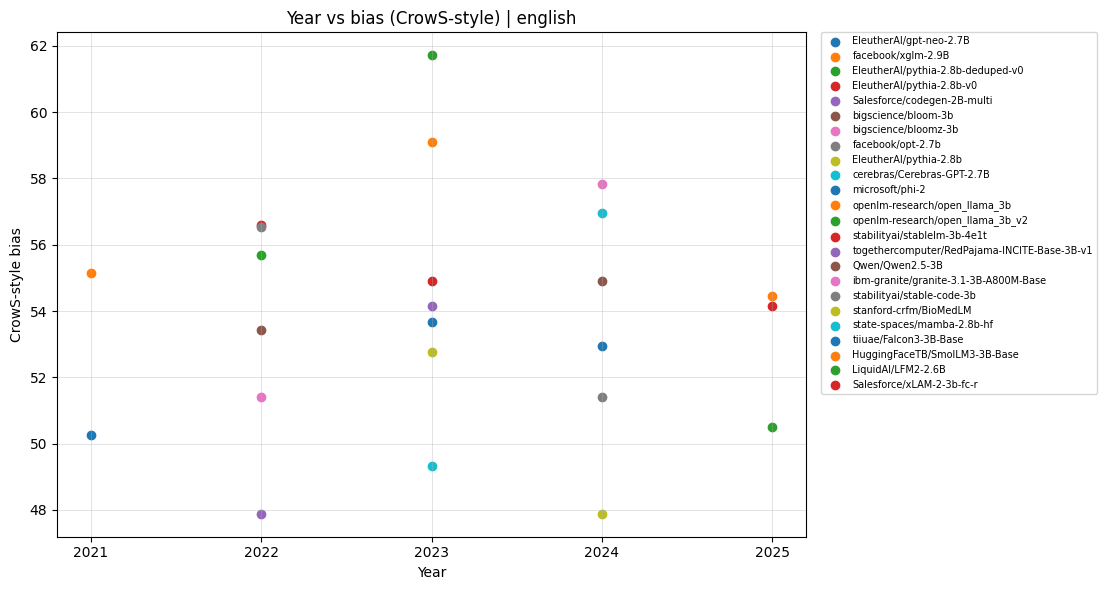

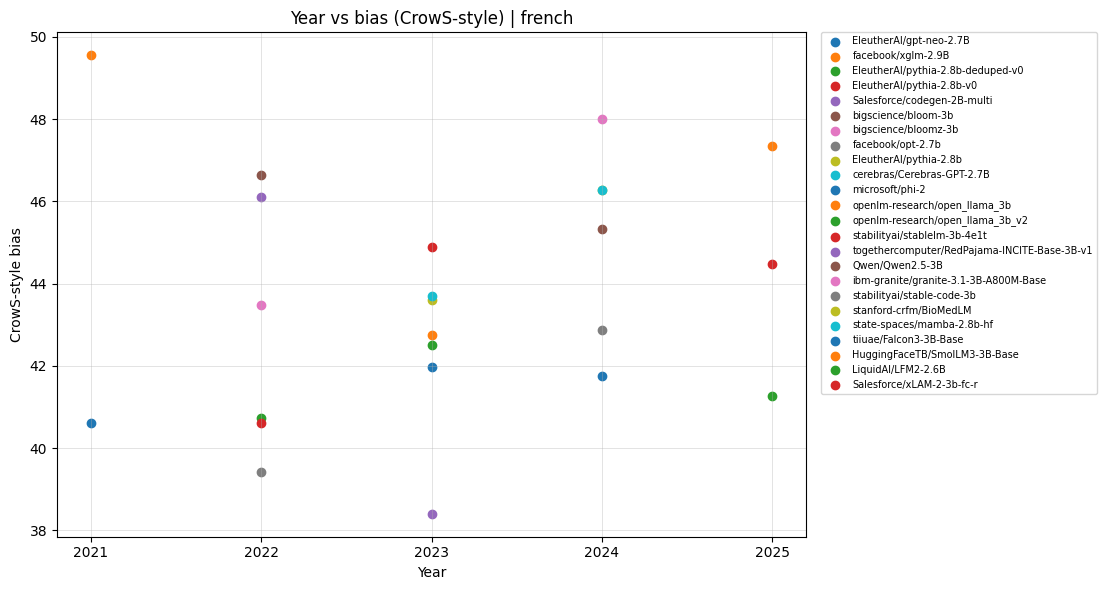

In [ ]:
# year vs bias, split by language 
for lang in sorted(dfb["lang"].unique()):
    scatter_models_legend(
        dfb[dfb["lang"] == lang],
        "year", "crows_bias",
        f"Year vs bias (CrowS-style) | {lang}",
        "Year", "CrowS-style bias",
        x_is_year=True
    )

ikke gode sammenligninger fordi fransk kommer fra multilingual datasættet og engelsk komme fra det originale datasæt
- burde compute både englsk og fransk fra multilingual datasættet

In [ ]:
# adding english + french into one table and compute per model differences

OUT_DIR = "results_fairness_over_time"
BIAS_EN_CSV = os.path.join(OUT_DIR, "bias_crows_pairs.csv")                 # english (old one)
BIAS_ML_CSV = os.path.join(OUT_DIR, "bias_crows_pairs_multilingual.csv")    # has french with a lang column

df_en = pd.read_csv(BIAS_EN_CSV)[["year","model_id","crows_bias"]].rename(columns={"crows_bias":"bias_english"})

df_ml = pd.read_csv(BIAS_ML_CSV)
df_fr = df_ml[df_ml["lang"].astype(str).str.lower().eq("french")][["year","model_id","crows_bias"]].rename(columns={"crows_bias":"bias_french"})

df_pair = df_en.merge(df_fr, on=["year","model_id"], how="inner")
df_pair["delta_french_minus_english"] = df_pair["bias_french"] - df_pair["bias_english"]

print("Paired rows:", len(df_pair))
print(df_pair[["year","model_id","bias_english","bias_french","delta_french_minus_english"]].head())
print("Mean delta (French - English):", df_pair["delta_french_minus_english"].mean())
print("Median delta (French - English):", df_pair["delta_french_minus_english"].median())
print("Mean absolute delta:", df_pair["delta_french_minus_english"].abs().mean())

Paired rows: 24
   year                           model_id  bias_english  bias_french  \
0  2021            EleutherAI/gpt-neo-2.7B     46.816976    40.608229   
1  2021                 facebook/xglm-2.9B     49.668435    49.552773   
2  2022  EleutherAI/pythia-2.8b-deduped-v0     56.299735    40.727490   
3  2022          EleutherAI/pythia-2.8b-v0     55.503979    40.608229   
4  2022        Salesforce/codegen-2B-multi     47.679045    46.094216   

   delta_french_minus_english  
0                   -6.208747  
1                   -0.115662  
2                  -15.572245  
3                  -14.895750  
4                   -1.584829  
Mean delta (French - English): -9.513237753514415
Median delta (French - English): -10.406771122488841
Mean absolute delta: 9.513237753514415


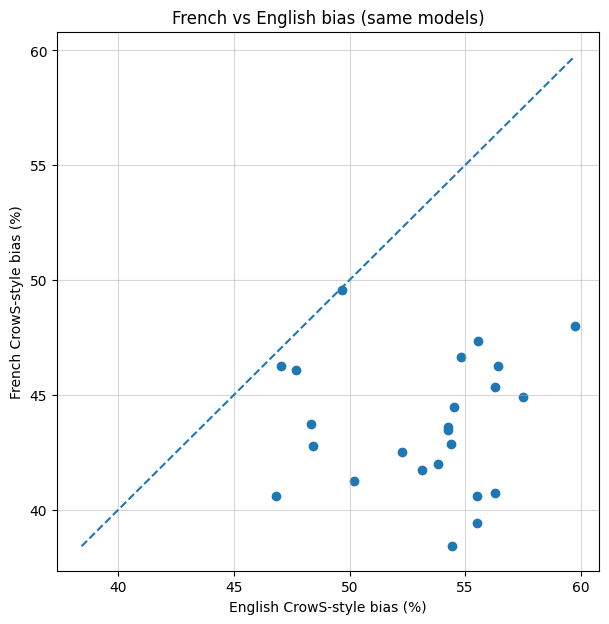

Pearson correlation: 0.03782221065639888
Spearman correlation (rank): 0.15081610803283862


In [6]:
# plotting french vs english directly

x = df_pair["bias_english"].to_numpy()
y = df_pair["bias_french"].to_numpy()

plt.figure(figsize=(7,7))
plt.scatter(x, y)

mn = float(min(x.min(), y.min()))
mx = float(max(x.max(), y.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--")  # y = x line

plt.xlabel("English CrowS-style bias (%)")
plt.ylabel("French CrowS-style bias (%)")
plt.title("French vs English bias (same models)")
plt.grid(True, alpha=0.5)
plt.show()

pearson_r = np.corrcoef(x, y)[0,1]
spearman_r = np.corrcoef(pd.Series(x).rank().to_numpy(), pd.Series(y).rank().to_numpy())[0,1]
print("Pearson correlation:", pearson_r)
print("Spearman correlation (rank):", spearman_r)

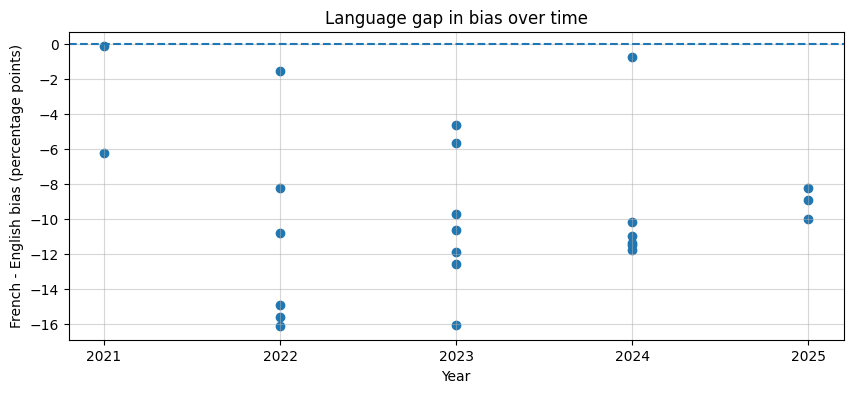

In [7]:
# plotting the difference over year (french - english)

plt.figure(figsize=(10,4))
plt.scatter(df_pair["year"], df_pair["delta_french_minus_english"])
plt.axhline(0, linestyle="--")
plt.xticks(sorted(df_pair["year"].unique()))
plt.xlabel("Year")
plt.ylabel("French - English bias (percentage points)")
plt.title("Language gap in bias over time")
plt.grid(True, alpha=0.5)
plt.show()

In [8]:
rng = np.random.default_rng(0)
d = df_pair["delta_french_minus_english"].to_numpy()

B = 20000
boot_means = rng.choice(d, size=(B, len(d)), replace=True).mean(axis=1)
low, high = np.quantile(boot_means, [0.025, 0.975])

print("Mean delta (French - English):", d.mean())
print("95% confidence interval for mean delta:", (low, high))

Mean delta (French - English): -9.513237753514415
95% confidence interval for mean delta: (np.float64(-11.213304023673913), np.float64(-7.679771729929614))
